# Dynamic Modeling with difflow

This notebook demonstrates the dynamic (transient) simulation capabilities of difflow.

**Topics covered:**
1. Basic ODE integration
2. Dynamic CSTR simulation (startup)
3. Dynamic flowsheets (multi-unit)
4. DAE systems (flash drum with VLE)
5. Diffrax backend for stiff systems
6. Gradient-based optimization of dynamic systems

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Configure JAX
jax.config.update("jax_enable_x64", True)

# Import difflow dynamic module
from difflow.dynamic import (
    integrate,
    integrate_unit,
    DynamicCSTR,
    DynamicTank,
    DynamicFlowsheet,
    integrate_dae,
    DynamicFlashDrum,
)
from difflow.streams import make_stream

W0000 00:00:1767315613.735974 9813634 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767315613.744629 9813634 service.cc:145] XLA service 0x600001f60a00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767315613.744639 9813634 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767315613.745597 9813634 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767315613.745603 9813634 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


## 1. Basic ODE Integration

The `integrate()` function provides a unified interface for solving ODEs.

### Example: Harmonic Oscillator

The harmonic oscillator is described by:
$$\frac{d^2x}{dt^2} = -x$$

As a first-order system:
$$\frac{dx}{dt} = v, \quad \frac{dv}{dt} = -x$$

In [2]:
def harmonic_oscillator(t, y):
    """Harmonic oscillator: d²x/dt² = -x"""
    x, v = y[0], y[1]
    return jnp.array([v, -x])

# Initial conditions: x=1, v=0
y0 = jnp.array([1.0, 0.0])

# Integrate for 3 periods
result = integrate(
    harmonic_oscillator,
    y0,
    t_span=(0.0, 6 * jnp.pi),
    method="RK4",
    n_steps=200,
)

print(f"Final state: x={result.y_final[0]:.4f}, v={result.y_final[1]:.4f}")
print(f"Steps taken: {result.info.n_steps}")

Final state: x=1.0000, v=0.0000
Steps taken: 200


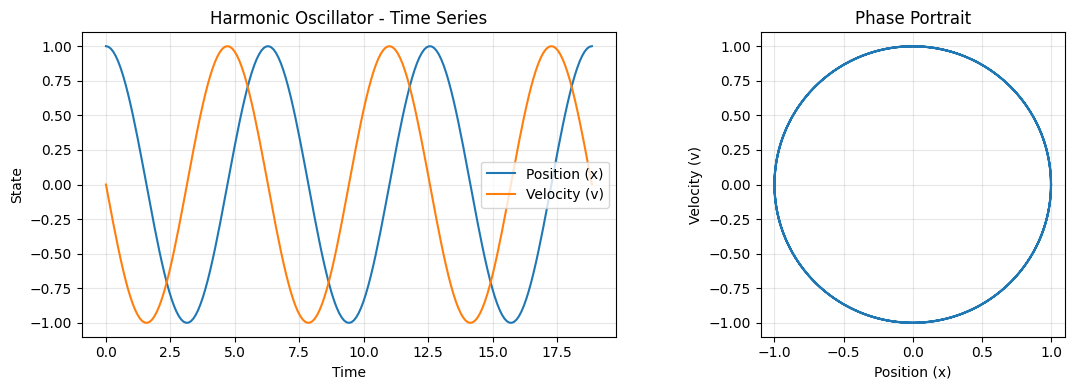

In [3]:
# Plot the trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Time series
ax1.plot(result.trajectory.t, result.trajectory.y[:, 0], label='Position (x)')
ax1.plot(result.trajectory.t, result.trajectory.y[:, 1], label='Velocity (v)')
ax1.set_xlabel('Time')
ax1.set_ylabel('State')
ax1.set_title('Harmonic Oscillator - Time Series')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Phase portrait
ax2.plot(result.trajectory.y[:, 0], result.trajectory.y[:, 1])
ax2.set_xlabel('Position (x)')
ax2.set_ylabel('Velocity (v)')
ax2.set_title('Phase Portrait')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Example: Exponential Decay

$$\frac{dy}{dt} = -ky$$

Exact solution: $y(t) = y_0 e^{-kt}$

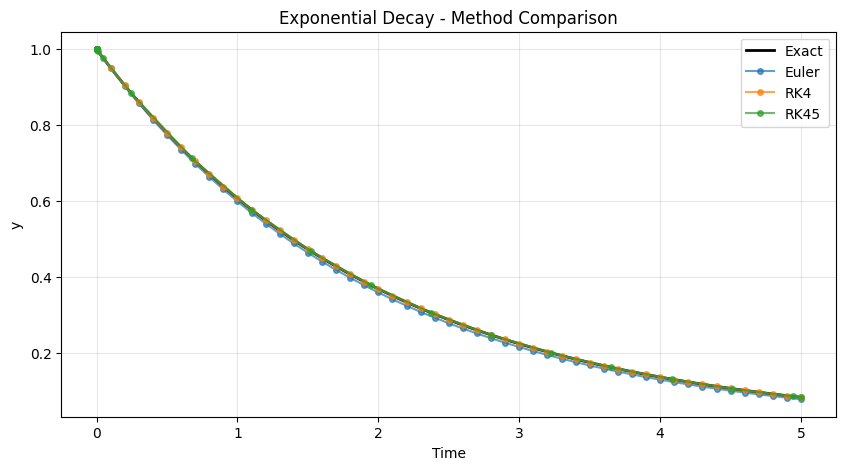

Final value errors:
  Euler: 5.14e-03
  RK4: 1.11e-08
  RK45: 9.15e-08


In [4]:
k = 0.5  # Decay rate

def exponential_decay(t, y):
    return -k * y

y0 = jnp.array([1.0])
t_span = (0.0, 5.0)

# Compare methods
methods = ["Euler", "RK4", "RK45"]
results = {}

for method in methods:
    if method == "RK45":
        results[method] = integrate(exponential_decay, y0, t_span, method=method, rtol=1e-6)
    else:
        results[method] = integrate(exponential_decay, y0, t_span, method=method, n_steps=50)

# Exact solution
t_exact = jnp.linspace(0, 5, 100)
y_exact = jnp.exp(-k * t_exact)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(t_exact, y_exact, 'k-', linewidth=2, label='Exact')

for method, result in results.items():
    plt.plot(result.trajectory.t, result.trajectory.y[:, 0], 'o-', 
             markersize=4, alpha=0.7, label=f'{method}')

plt.xlabel('Time')
plt.ylabel('y')
plt.title('Exponential Decay - Method Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print final errors
y_exact_final = float(jnp.exp(-k * t_span[1]))
print("Final value errors:")
for method, result in results.items():
    error = abs(float(result.y_final[0]) - y_exact_final)
    print(f"  {method}: {error:.2e}")

## 2. Dynamic CSTR Simulation

Simulate the startup of a CSTR with reaction A → B.

In [5]:
# Define reaction kinetics: r = k * C_A
def rate_fn(C, T, params):
    k = params["k"]
    return jnp.array([k * C["A"]])

# Stoichiometry: A → B
stoich = jnp.array([
    [-1.0],  # A consumed
    [+1.0],  # B produced
])

# Create dynamic CSTR
cstr = DynamicCSTR(
    volume=1.0,  # m³
    rate_fn=rate_fn,
    stoich=stoich,
    species_order=["A", "B"],
    rate_params={"k": 0.1},  # rate constant (1/s)
    name="reactor",
)

print(f"CSTR state variables: {cstr.state_spec().names}")
print(f"Number of states: {cstr.state_spec().n_states}")

CSTR state variables: ['n_A', 'n_B']
Number of states: 2


In [6]:
# Create inlet stream
inlet = make_stream({"A": 1.0, "B": 0.0}, T=350.0, P=101325.0)
print(f"Inlet: F_A={inlet['F_A']:.2f} mol/s, F_B={inlet['F_B']:.2f} mol/s")

# Simulate startup (from initial state based on inlet)
result = integrate_unit(
    cstr,
    inputs={"inlet": inlet},
    t_span=(0.0, 100.0),  # 100 seconds
    method="RK4",
    n_steps=200,
)

print(f"\nFinal state:")
print(f"  n_A = {result.y_final[0]:.4f} mol")
print(f"  n_B = {result.y_final[1]:.4f} mol")
print(f"  Total moles = {result.y_final[0] + result.y_final[1]:.4f} mol")

Inlet: F_A=1.00 mol/s, F_B=0.00 mol/s

Final state:
  n_A = 8.5719 mol
  n_B = 51.4281 mol
  Total moles = 60.0000 mol


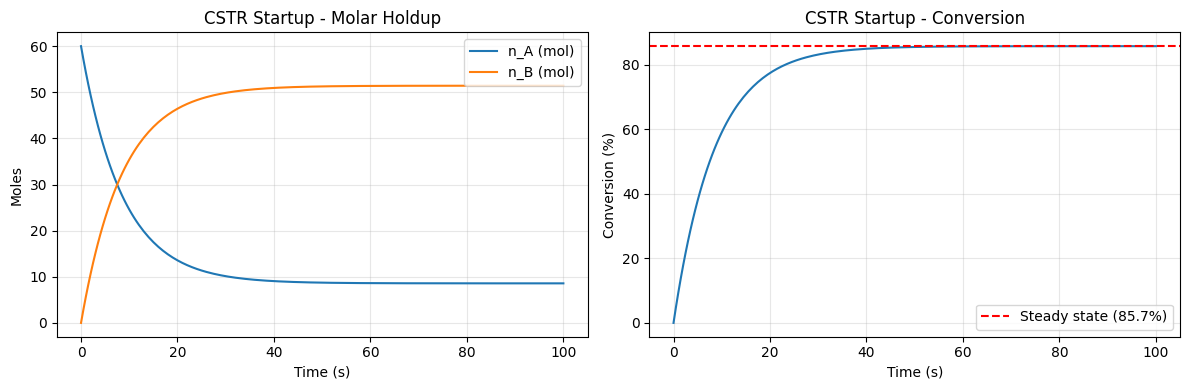

In [7]:
# Plot CSTR dynamics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Molar holdup
ax1.plot(result.trajectory.t, result.trajectory.y[:, 0], label='n_A (mol)')
ax1.plot(result.trajectory.t, result.trajectory.y[:, 1], label='n_B (mol)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Moles')
ax1.set_title('CSTR Startup - Molar Holdup')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Conversion
n_A = result.trajectory.y[:, 0]
n_B = result.trajectory.y[:, 1]
conversion = n_B / (n_A + n_B + 1e-10)  # Mole fraction of B = conversion

ax2.plot(result.trajectory.t, conversion * 100)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Conversion (%)')
ax2.set_title('CSTR Startup - Conversion')
ax2.grid(True, alpha=0.3)

# Steady-state conversion (analytical)
# For CSTR: X = k*tau / (1 + k*tau) where tau = n_total / F_total
# At steady state, n_total ≈ 60 mol (from initial_state: tau=60s * F=1 mol/s)
# F_total = 1.0 mol/s
k = 0.1
tau = 60.0  # residence time = holdup / flow rate
X_ss = k * tau / (1 + k * tau)
ax2.axhline(X_ss * 100, color='r', linestyle='--', label=f'Steady state ({X_ss*100:.1f}%)')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Dynamic Flowsheet

Connect multiple units: CSTR → Storage Tank

In [8]:
# Create a storage tank
tank = DynamicTank(
    max_volume=10.0,  # m³
    species_order=["A", "B"],
    name="storage",
)

# Build flowsheet
fs = DynamicFlowsheet(species_order=["A", "B"])

# Add feed
feed = make_stream({"A": 1.0, "B": 0.0}, T=350.0, P=101325.0)
fs.add_feed("feed", feed)

# Add units
fs.add_unit(cstr, inlet_names=["feed"], outlet_names=["reactor_out"])
fs.add_unit(tank, inlet_names=["reactor_out"], outlet_names=["product"])

print(f"Flowsheet units: {[u.name for u in fs._units]}")
print(f"Total states: {sum(u.unit.state_spec().n_states for u in fs._units)}")

Flowsheet units: ['reactor', 'storage']
Total states: 5


In [9]:
# Simulate flowsheet
result = fs.simulate(
    t_span=(0.0, 200.0),
    method="RK4",
    n_steps=400,
)

print(f"Final combined state: {result.y_final}")
print(f"Success: {result.info.success}")

Final combined state: [  8.57142858  51.42857143   5.         135.41745823 114.58254177]
Success: True


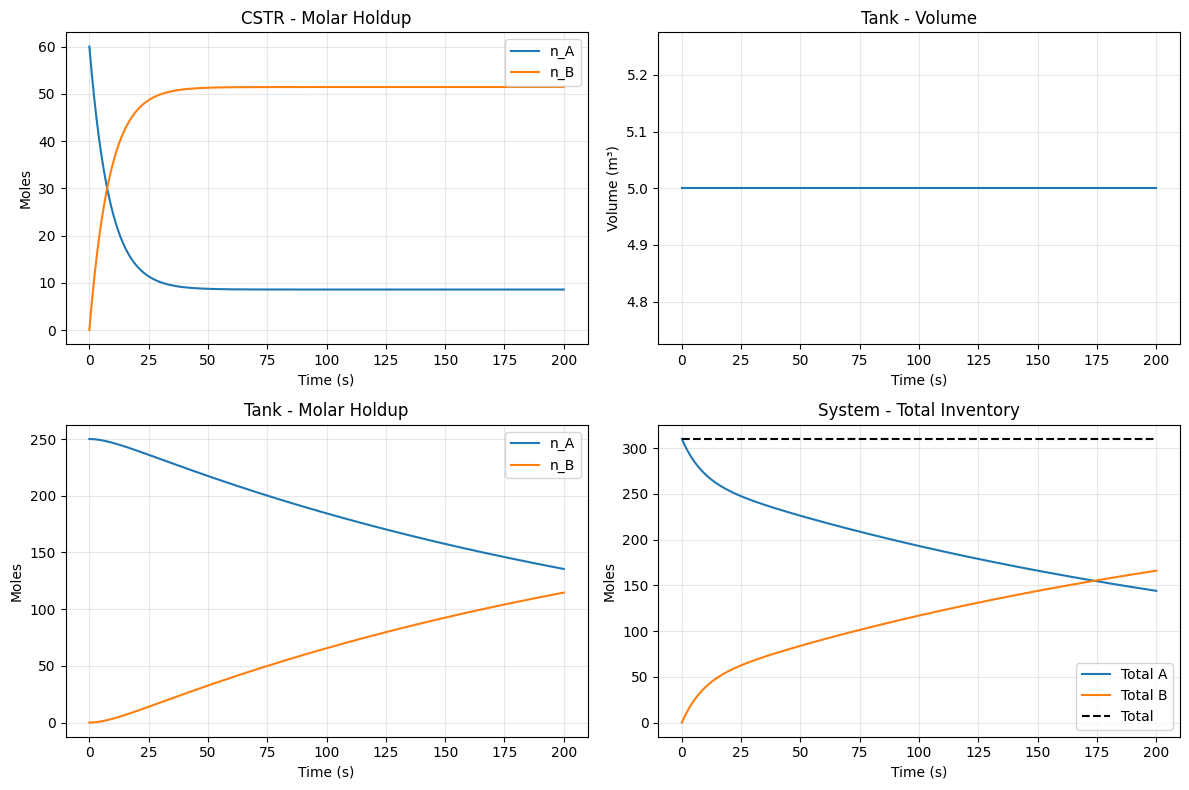

In [10]:
# Extract per-unit states
# CSTR: states 0-1 (n_A, n_B)
# Tank: states 2-4 (V, n_A, n_B)
cstr_states = result.trajectory.y[:, :2]
tank_states = result.trajectory.y[:, 2:]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# CSTR moles
axes[0, 0].plot(result.trajectory.t, cstr_states[:, 0], label='n_A')
axes[0, 0].plot(result.trajectory.t, cstr_states[:, 1], label='n_B')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Moles')
axes[0, 0].set_title('CSTR - Molar Holdup')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Tank volume
axes[0, 1].plot(result.trajectory.t, tank_states[:, 0])
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Volume (m³)')
axes[0, 1].set_title('Tank - Volume')
axes[0, 1].grid(True, alpha=0.3)

# Tank moles
axes[1, 0].plot(result.trajectory.t, tank_states[:, 1], label='n_A')
axes[1, 0].plot(result.trajectory.t, tank_states[:, 2], label='n_B')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Moles')
axes[1, 0].set_title('Tank - Molar Holdup')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Total system inventory
total_A = cstr_states[:, 0] + tank_states[:, 1]
total_B = cstr_states[:, 1] + tank_states[:, 2]
axes[1, 1].plot(result.trajectory.t, total_A, label='Total A')
axes[1, 1].plot(result.trajectory.t, total_B, label='Total B')
axes[1, 1].plot(result.trajectory.t, total_A + total_B, 'k--', label='Total')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Moles')
axes[1, 1].set_title('System - Total Inventory')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. DAE Systems

Differential-Algebraic Equations combine ODEs with algebraic constraints.

Example: Flash drum where vapor-liquid equilibrium must be satisfied at each time step.

In [11]:
# Create flash drum with VLE equilibrium
# K_func returns K-values for each species given temperature
def K_func(T):
    # Simple constant K-values: A is more volatile (K=2), B less (K=0.5)
    return jnp.array([2.0, 0.5])

flash = DynamicFlashDrum(
    volume=1.0,
    species_order=["A", "B"],
    K_func=K_func,
    name="flash",
)

print(f"Differential states: {flash.state_spec().names}")
print(f"Algebraic states: {flash.algebraic_spec().names}")

Differential states: ['n_A', 'n_B', 'H']
Algebraic states: ['beta']


In [12]:
# Feed with 50/50 mixture
flash_feed = make_stream({"A": 0.5, "B": 0.5}, T=350.0, P=101325.0)

# Integrate DAE
dae_result = integrate_dae(
    flash,
    inputs={"inlet": flash_feed},
    t_span=(0.0, 50.0),
    method="RK4",
    n_steps=100,
)

print(f"Final differential states (moles): {dae_result.x_final}")
print(f"Final algebraic states (V_frac): {dae_result.z_final}")

Final differential states (moles): [30. 30.  0.]
Final algebraic states (V_frac): [0.5]


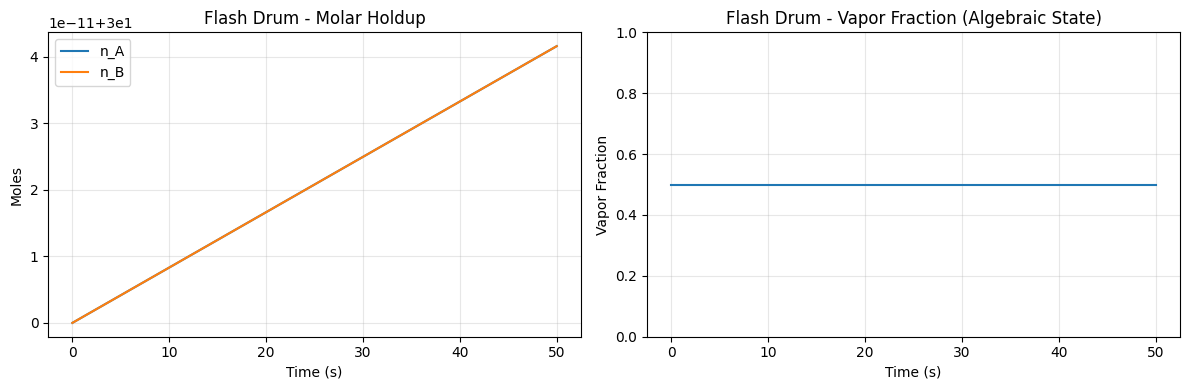

In [13]:
# Plot DAE results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Molar holdup
ax1.plot(dae_result.t_history, dae_result.x_history[:, 0], label='n_A')
ax1.plot(dae_result.t_history, dae_result.x_history[:, 1], label='n_B')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Moles')
ax1.set_title('Flash Drum - Molar Holdup')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Vapor fraction (algebraic variable)
ax2.plot(dae_result.t_history, dae_result.z_history[:, 0])
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Vapor Fraction')
ax2.set_title('Flash Drum - Vapor Fraction (Algebraic State)')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Diffrax Backend

For advanced solvers (adaptive step, stiff systems), use the diffrax backend.

In [14]:
# Check if diffrax is available
from difflow.dynamic import check_diffrax_available, list_diffrax_solvers

if check_diffrax_available():
    print("Diffrax is available!")
    print(f"Available solvers: {list_diffrax_solvers()}")
else:
    print("Diffrax not installed. Install with: pip install diffrax")

Diffrax is available!
Available solvers: ['bosh3', 'dopri5', 'dopri8', 'euler', 'heun', 'implicit_euler', 'kvaerno3', 'kvaerno4', 'kvaerno5', 'leapfrog_midpoint', 'midpoint', 'ralston', 'semi_implicit_euler', 'tsit5']


Final state: x=2.0081, v=-0.0425
Steps taken: 219


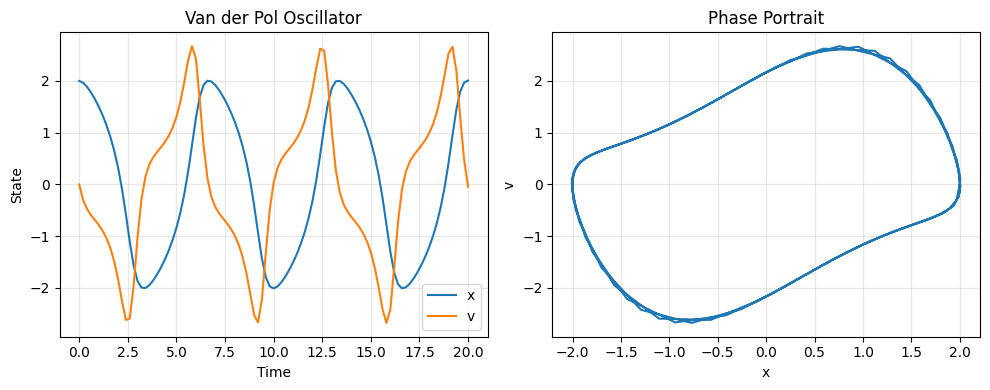

In [15]:
# Example: Using adaptive solvers for better accuracy
if check_diffrax_available():
    # Van der Pol oscillator - a moderately stiff oscillator
    # mu controls stiffness - higher values make it stiffer
    mu = 1.0  # Moderate stiffness
    
    def vanderpol(t, y):
        x, v = y[0], y[1]
        dx = v
        dv = mu * (1 - x**2) * v - x
        return jnp.array([dx, dv])

    y0 = jnp.array([2.0, 0.0])

    # Use adaptive Dopri5 solver
    result = integrate(
        vanderpol, y0,
        t_span=(0.0, 20.0),
        method="diffrax:dopri5",
        rtol=1e-6, atol=1e-8,
    )

    print(f"Final state: x={result.y_final[0]:.4f}, v={result.y_final[1]:.4f}")
    print(f"Steps taken: {result.info.n_steps}")
    
    # Plot phase portrait
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(result.trajectory.t, result.trajectory.y[:, 0], label='x')
    plt.plot(result.trajectory.t, result.trajectory.y[:, 1], label='v')
    plt.xlabel('Time')
    plt.ylabel('State')
    plt.title('Van der Pol Oscillator')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(result.trajectory.y[:, 0], result.trajectory.y[:, 1])
    plt.xlabel('x')
    plt.ylabel('v')
    plt.title('Phase Portrait')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping example (diffrax not installed)")

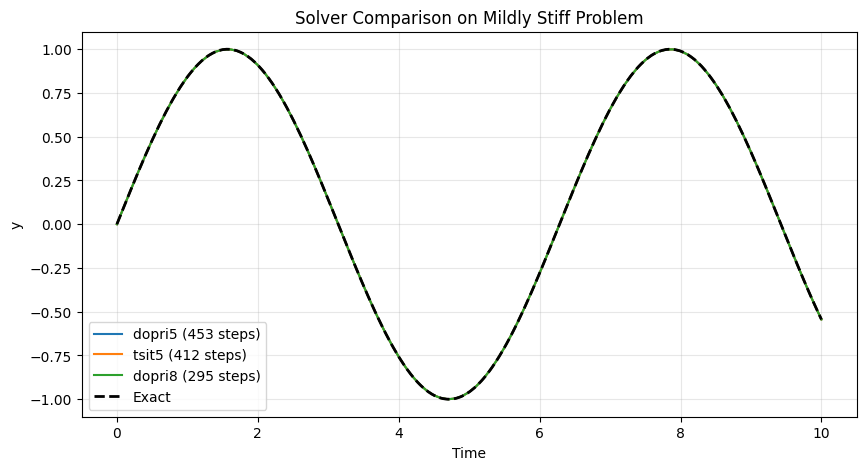

In [16]:
# Compare different explicit solvers on mildly stiff problem
if check_diffrax_available():
    # Mildly stiff decay: y' = -100*(y - sin(t)) + cos(t)
    # Exact solution: y = sin(t)
    def stiff_decay(t, y):
        return -100 * (y - jnp.sin(t)) + jnp.cos(t)

    y0 = jnp.array([0.0])
    t_span = (0.0, 10.0)

    # Compare explicit adaptive solvers
    solvers = ["dopri5", "tsit5", "dopri8"]
    results = {}

    for solver in solvers:
        results[solver] = integrate(
            stiff_decay, y0, t_span,
            method=f"diffrax:{solver}",
            rtol=1e-5, atol=1e-7,
        )

    # Plot
    plt.figure(figsize=(10, 5))
    for solver, result in results.items():
        plt.plot(result.trajectory.t, result.trajectory.y[:, 0], 
                 label=f'{solver} ({result.info.n_steps} steps)')

    # Exact solution: y = sin(t)
    t_exact = jnp.linspace(0, 10, 200)
    plt.plot(t_exact, jnp.sin(t_exact), 'k--', linewidth=2, label='Exact')

    plt.xlabel('Time')
    plt.ylabel('y')
    plt.title('Solver Comparison on Mildly Stiff Problem')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 6. Gradient-Based Optimization

All dynamic simulations are differentiable via JAX autodiff.

In [17]:
# Optimize rate constant to maximize conversion
def simulate_cstr(k):
    """Simulate CSTR with rate constant k, return final product."""
    def rate_fn(C, T, params):
        return jnp.array([k * C["A"]])

    cstr = DynamicCSTR(
        volume=1.0,
        rate_fn=rate_fn,
        stoich=jnp.array([[-1.0], [1.0]]),
        species_order=["A", "B"],
        rate_params={},
    )

    inlet = make_stream({"A": 1.0, "B": 0.0}, T=350.0, P=101325.0)
    result = integrate_unit(cstr, {"inlet": inlet}, (0.0, 50.0), method="RK4", n_steps=100)
    
    # Return final B amount
    return result.y_final[1]

# Compute gradient
k_val = jnp.array(0.1)
product = simulate_cstr(k_val)
grad_k = jax.grad(simulate_cstr)(k_val)

print(f"At k = {k_val}:")
print(f"  Final product: {product:.4f} mol")
print(f"  d(product)/dk: {grad_k:.4f}")

At k = 0.1:
  Final product: 51.2780 mol
  d(product)/dk: 80.7842


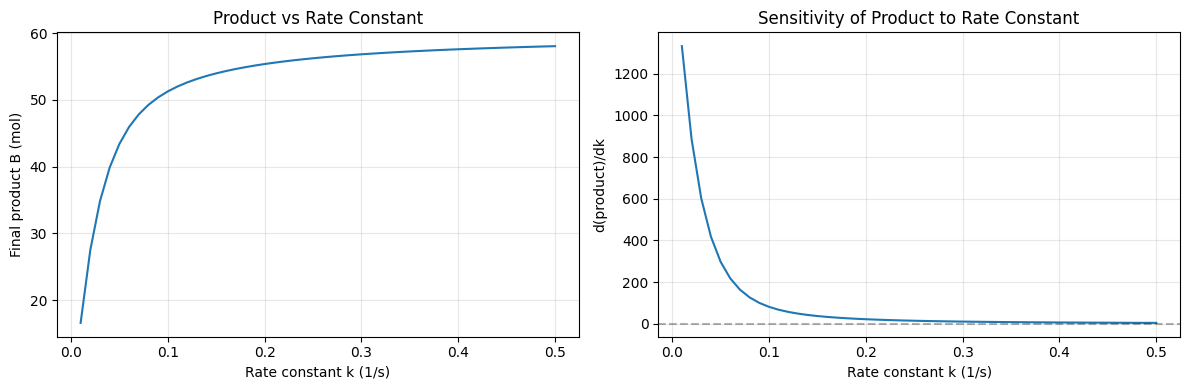

In [18]:
# Parameter sensitivity analysis
k_values = jnp.linspace(0.01, 0.5, 50)
products = jax.vmap(simulate_cstr)(k_values)
gradients = jax.vmap(jax.grad(simulate_cstr))(k_values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_values, products)
ax1.set_xlabel('Rate constant k (1/s)')
ax1.set_ylabel('Final product B (mol)')
ax1.set_title('Product vs Rate Constant')
ax1.grid(True, alpha=0.3)

ax2.plot(k_values, gradients)
ax2.set_xlabel('Rate constant k (1/s)')
ax2.set_ylabel('d(product)/dk')
ax2.set_title('Sensitivity of Product to Rate Constant')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Gradient descent optimization of rate constant k:
--------------------------------------------------


  Iter  20: k = 0.0892, loss = 40.17


  Iter  40: k = 0.0607, loss = 2.85


  Iter  60: k = 0.0554, loss = 0.03


  Iter  80: k = 0.0547, loss = 0.07


  Iter 100: k = 0.0559, loss = 0.00

Optimal k: 0.0559
Final product: 44.99 mol (target: 45.0)


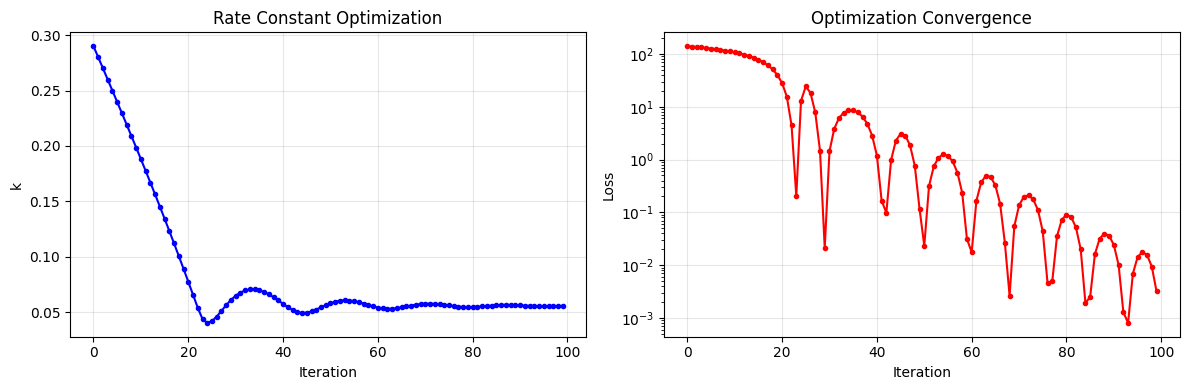

In [19]:
# Gradient descent to find optimal k for target conversion
import optax  # Use adaptive optimizer for better convergence

def loss(k):
    """Squared error from target product amount."""
    target = 45.0  # Target 45 mol of B (achievable in range k=0.01-0.5)
    product = simulate_cstr(k)
    return (product - target)**2

# Use Adam optimizer for adaptive learning rates
optimizer = optax.adam(learning_rate=0.01)
k = jnp.array(0.3)  # Initial guess - start high to see decrease
opt_state = optimizer.init(k)
history = []

print("Gradient descent optimization of rate constant k:")
print("-" * 50)

for i in range(100):
    l = loss(k)
    g = jax.grad(loss)(k)
    updates, opt_state = optimizer.update(g, opt_state, k)
    k = optax.apply_updates(k, updates)
    k = jnp.clip(k, 0.01, 1.0)  # Keep k in valid range
    history.append((float(k), float(l)))
    
    if (i + 1) % 20 == 0:
        print(f"  Iter {i+1:3d}: k = {float(k):.4f}, loss = {float(l):.2f}")

print(f"\nOptimal k: {k:.4f}")
print(f"Final product: {simulate_cstr(k):.2f} mol (target: 45.0)")

# Plot optimization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot([h[0] for h in history], 'b-o', markersize=3)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('k')
ax1.set_title('Rate Constant Optimization')
ax1.grid(True, alpha=0.3)

ax2.semilogy([h[1] for h in history], 'r-o', markersize=3)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.set_title('Optimization Convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The `difflow.dynamic` module provides:

1. **Unified ODE integration** via `integrate()` with multiple methods (RK4, RK45, Euler, diffrax)

2. **Dynamic unit operations** (`DynamicCSTR`, `DynamicTank`) implementing the `DynamicUnit` protocol

3. **Multi-unit flowsheets** via `DynamicFlowsheet` for connected process simulation

4. **DAE support** for systems with algebraic constraints (VLE, etc.)

5. **Advanced solvers** via diffrax backend for stiff systems

6. **Full differentiability** enabling gradient-based optimization of dynamic systems

See `docs/dynamic-modeling.md` for complete API documentation.